In [1]:
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ethanol_production import create_cellulosic_ethanol_system
from biorefineries import cellulosic

from biosteam import main_flowsheet as F
import biosteam as bst


chems = cellulosic.create_cellulosic_ethanol_chemicals().copy()

bst.settings.set_thermo(chems)

chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

etoh_system = create_cellulosic_ethanol_system(ins=poplar_in)
etoh_system.simulate()

# --- Explicitly route the same streams the stock system routes ---
# Verified against cellulosic.create_cellulosic_ethanol_system (solo_ethanol.py):
#   WWT M601 <- pretreatment_wastewater + S401.outs[1] (stillage filtrate, s48)
#   BT ins[0] <- S401.outs[0] (filter cake) + WWT sludge via solids_to_BT mixer
#   BT ins[1] <- WWT biogas only (fermentation vent is atmospheric, not burned)
#   PWC ins[0] <- WWT.outs[2] (RO treated water, ~479,000 kg/hr)
#       In the stock system this is wired via M4 (a pass-through mixer from S604).
#       Here we wire directly since M2 (the placeholder mixer created by
#       create_all_facilities when WWT=False) has no inlets and is inert.
#   CT blowdown -> PWC via blowdown_recycle=True (matches stock factory default)
#   brine (WWT.outs[3]) -> unconnected, same as stock system

etoh_ww     = [F.pretreatment_wastewater, F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=etoh_ww)

# Wire WWT RO-treated water back to PWC — in the stock system create_all_facilities(WWT=True)
# does this automatically via M4. Here we bypass the empty placeholder M2 and connect
# directly. The WWT->PWC feedback is weak enough that no iterative convergence is needed.
F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)
gas_mixer    = bst.Mixer('MIX_BT_gas',    ins=[WWT.outs[0]])

BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=0.2612)
BT.ins[0] = solids_to_BT.outs[0]
BT.ins[1] = gas_mixer.outs[0]

combined_etoh_system = bst.System(
    'Combined_Ethanol_System',
    path=(etoh_system, WWT),
    facilities=[solids_to_BT, gas_mixer, BT],
)
combined_etoh_system.simulate()


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\pressure_vessel.py:104: CostWarning: <RefluxDrum: reflux_drum> Vertical vessel length (9 ft) is out of bounds (12 to 40 ft) for cost correlation
  return method(pressure, diameter, length)


In [2]:
combined_etoh_system

System: Combined_Ethanol_System
Highest convergence error among components in recycle
stream T301-0 after 1 loops:
- flow rate   3.12e-04 kmol/hr (0.0057%)
- temperature 0.00e+00 K (0%)
ins...
[0] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water    925
                    Sucrose  0.243
                    Extract  7.4
                    Acetate  48.6
                    Ash      1e+03
                    Lignin   156
                    Glucan   238
                    ...      112
[1] warm_process_water_1  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  1.3e+03
[2] pretreatment_steam  
    phase: 'g', T: 541.15 K, P: 1.31722e+06 Pa
    flow (kmol/hr): Water  1.76e+03
[3] warm_process_water_2  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  8.79e+03
[4] ammonia_process_water  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  4.96e+03
[5] sulfuric_acid  
    phase: 'l', T: 294.15 K, P: 54715

In [2]:
tea_test_desu = create_cellulosic_ethanol_tea(combined_etoh_system)


In [3]:
print(f'The MSP for ethanol is  {round(tea_test_desu.solve_price(combined_etoh_system.products[1]), 3)} USD/kg')


The MSP for ethanol is  0.787 USD/kg


In [1]:
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ethanol_production import create_cellulosic_ethanol_system
from biorefineries import cellulosic
from cellulosic_tea import create_cellulosic_ethanol_tea


from biosteam import main_flowsheet as F
import biosteam as bst


chems = cellulosic.create_cellulosic_ethanol_chemicals().copy()

bst.settings.set_thermo(chems)

chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

etoh_system = create_cellulosic_ethanol_system(ins=poplar_in)
etoh_system.simulate()

# --- Route unconnected outlets to shared utilities ---

etoh_product  = set(etoh_system.outs)
etoh_unrouted = [s for s in etoh_system.streams
                 if s.sink is None and s.source is not None
                 and s not in etoh_product and s.F_mass > 0]
etoh_gases  = [s for s in etoh_unrouted if s.phase == 'g']
etoh_solids = [F.unit.S401.outs[0]]
etoh_ww     = [s for s in etoh_unrouted
               if s not in etoh_gases and s is not F.unit.S401.outs[0]]

# WWT — receives all wastewater streams
WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=etoh_ww)

# BT — solids slot combines WWT sludge + filter cake
solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)

# BT — gas slot combines fermentation gases + WWT biogas
gas_mixer = bst.Mixer('MIX_BT_gas', ins=etoh_gases + [WWT.outs[0]])

BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=0.2612)
BT.ins[0] = solids_to_BT.outs[0]
BT.ins[1] = gas_mixer.outs[0]

# --- Assemble and simulate the closed system ---

combined_etoh_system = bst.System(
    'Combined_Ethanol_System',
    path=(etoh_system, WWT),
    facilities=[solids_to_BT, gas_mixer, BT],
)
combined_etoh_system.simulate()


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\pressure_vessel.py:104: CostWarning: <RefluxDrum: reflux_drum> Vertical vessel length (9 ft) is out of bounds (12 to 40 ft) for cost correlation
  return method(pressure, diameter, length)


In [ ]:
tea_testtt = create_cellulosic_ethanol_tea(combined_etoh_system)


In [3]:
combined_etoh_system

System: Combined_Ethanol_System
Highest convergence error among components in recycle
stream T301-0 after 1 loops:
- flow rate   3.12e-04 kmol/hr (0.0057%)
- temperature 0.00e+00 K (0%)
ins...
[0] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water    925
                    Sucrose  0.243
                    Extract  7.4
                    Acetate  48.6
                    Ash      1e+03
                    Lignin   156
                    Glucan   238
                    ...      112
[1] warm_process_water_1  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  1.3e+03
[2] pretreatment_steam  
    phase: 'g', T: 541.15 K, P: 1.31722e+06 Pa
    flow (kmol/hr): Water  1.76e+03
[3] warm_process_water_2  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  8.79e+03
[4] ammonia_process_water  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  4.96e+03
[5] sulfuric_acid  
    phase: 'l', T: 294.15 K, P: 54715

In [4]:
print(f'The MSP for ethanol is  {round(tea_testtt.solve_price(combined_etoh_system.products[0]), 3)} USD/kg')


The MSP for ethanol is  1.441 USD/kg


In [1]:
from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ligsaf_system import create_rcf_system
from lignin_saf.ligsaf_purification_system import create_rcf_oil_purification_system
from lignin_saf.monomer_purification import create_monomer_purification_system
from lignin_saf.ligsaf_utilities_system import create_rcf_utilities_system
from lignin_saf.ethanol_production import create_cellulosic_ethanol_system
from cellulosic_tea import create_cellulosic_ethanol_tea
from biorefineries import cellulosic


from biosteam import main_flowsheet as F
import thermosteam as tmo
import biosteam as bst
import pandas as pd
import numpy as np

In [2]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
bst.nbtutorial() # Light-mode html diagrams and filter warnings

In [4]:
chems = cellulosic.create_cellulosic_ethanol_chemicals().copy()


In [5]:
bst.settings.set_thermo(chems) # Setting thermodynamic property pacakge for the chemicals


In [6]:
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

In [7]:
incomplete_etoh_system = create_cellulosic_ethanol_system(ins = poplar_in)
incomplete_etoh_system.simulate()

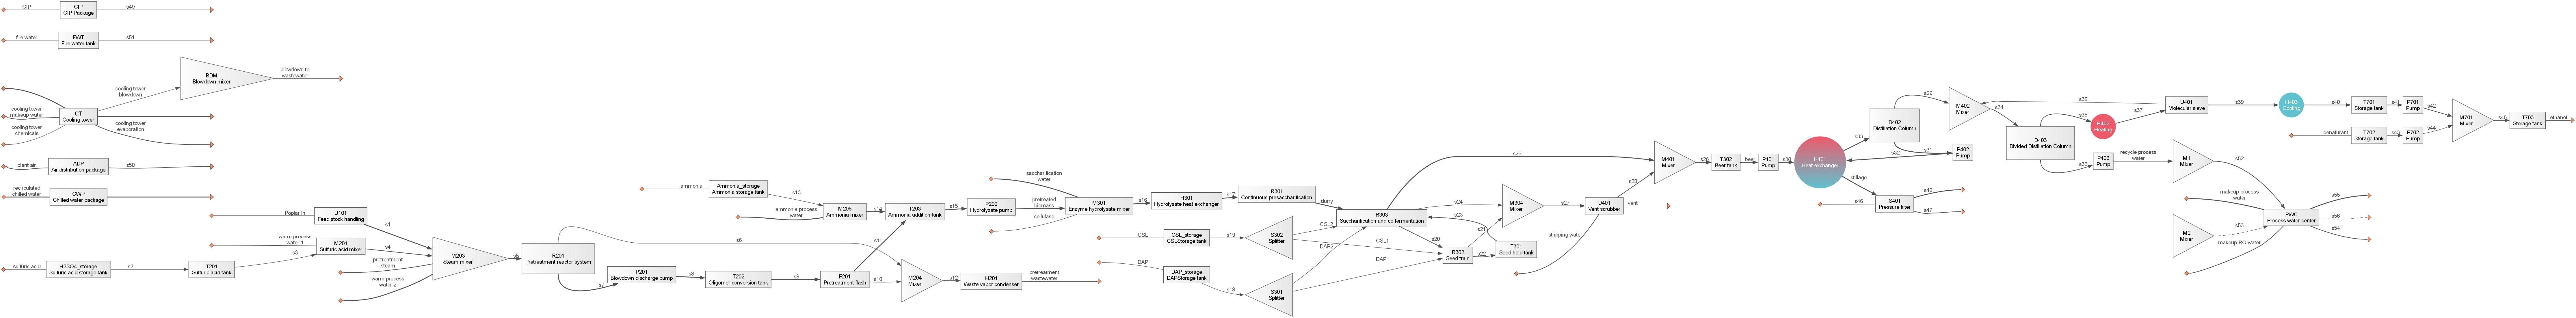

In [8]:
incomplete_etoh_system.diagram(format = 'png')

In [9]:
incomplete_etoh_system.show()

System: cornstover_sys
Highest convergence error among components in recycle
stream T301-0 after 2 loops:
- flow rate   0.00e+00 kmol/hr (0%)
- temperature 0.00e+00 K (0%)
ins...
[0] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water    925
                    Sucrose  0.243
                    Extract  7.4
                    Acetate  48.6
                    Ash      1e+03
                    Lignin   156
                    Glucan   238
                    ...      112
[1] sulfuric_acid  
    phase: 'l', T: 294.15 K, P: 547155 Pa
    flow (kmol/hr): Water  7.22
                    H2SO4  18.4
[2] ammonia  
    phase: 'l', T: 298.15 K, P: 1.2159e+06 Pa
    flow (kmol/hr): NH3    1
                    NH4OH  36.7
[3] denaturant  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Denaturant  4.51
outs...
[0] ethanol  
    phase: 'l', T: 339.26 K, P: 101325 Pa
    flow (kmol/hr): Water       10.7
                    Ethanol     504
              

In [10]:
tea_test_2 = create_cellulosic_ethanol_tea(incomplete_etoh_system)


In [13]:
incomplete_etoh_system.products[1]

Stream: ethanol from <StorageTank: T703>
phase: 'l', T: 339.26 K, P: 101325 Pa
flow (kmol/hr): Water       10.7
                Ethanol     504
                NH3         0.818
                Denaturant  4.51


In [14]:
print(f'The MSP for ethanol is  {round(tea_test_2.solve_price(incomplete_etoh_system.products[1]), 3)} USD/kg')


The MSP for ethanol is  0.87 USD/kg


In [15]:
incomplete_etoh_system.products

[<Stream: vent>,
 <Stream: ethanol>,
 <Stream: s47>,
 <Stream: s48>,
 <Stream: pretreatment_wastewater>,
 <Stream>,
 <Stream: s50>,
 <Stream>,
 <Stream: cooling_tower_evaporation>,
 <Stream: s51>,
 <Stream: s49>,
 <Stream: s54>,
 <Stream: s55>,
 <Stream: s56>,
 <Stream: blowdown_to_wastewater>]

In [16]:
print('CAPEX', round(incomplete_etoh_system.installed_equipment_cost / 1e6, 2), 'MMUSD')
print('OPEX', round((incomplete_etoh_system.material_cost + incomplete_etoh_system.utility_cost) / 1e6, 3), 'MMUSD/yr')

CAPEX 111.2 MMUSD
OPEX 129.931 MMUSD/yr


In [18]:
etoh_product = set(incomplete_etoh_system.outs)
etoh_unrouted = [s for s in incomplete_etoh_system.streams
                 if s.sink is None and s.source is not None
                 and s not in etoh_product and s.F_mass > 0]
etoh_gases  = [s for s in etoh_unrouted if s.phase == 'g']
etoh_solids = [F.unit.S401.outs[0]]
etoh_ww     = [s for s in etoh_unrouted
               if s not in etoh_gases and s is not F.unit.S401.outs[0]]


In [20]:
BT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)   # Boiler turbogenerator


In [25]:
etoh_gases

[<Stream: vent>, <Stream: cooling_tower_evaporation>]

In [28]:
etoh_solids

[<Stream: s47>]

In [29]:
etoh_ww

[<Stream: s48>,
 <Stream: pretreatment_wastewater>,
 <Stream>,
 <Stream: s50>,
 <Stream>,
 <Stream: s51>,
 <Stream: s49>,
 <Stream: s54>,
 <Stream: s55>,
 <Stream: blowdown_to_wastewater>]

In [24]:
BT.ins[1] = etoh_gases             # Takes in the purge gases from PSA 
#WWT = create_conventional_wastewater_treatment_system(ins=wastewater_mixer.outs[0]) 

TypeError: 'Inlets' object can only contain streams; not 'list' objects

In [ ]:
#WWT = create_conventional_wastewater_treatment_system(ins=wastewater_mixer.outs[0]) 

In [17]:
F.BT

AttributeError: no registered item 'BT'